# Monte Carlo Simulation

## Load the Libs we need

In [1]:
# Core
import math
import time
import random

# Numerical
import numpy as np

# Plotting
import matplotlib.pyplot as plt

# Distributions
from scipy.stats import t as student_t

# LSM regression
from sklearn.linear_model import LinearRegression

## A simple Pi Example

In [2]:
def mb_estimate_pi(n):
    """
    Estimates the value of π using a Monte Carlo Simulation approach.

    The function randomly generates points within a unit square and
    counts how many fall inside the corresponding quarter-circle.
    The ratio of points inside the circle to the total number of points
    is used to approximate π.

    Parameters
    ----------
    n : int
        Number of random points (simulations) to generate.

    Returns
    -------
    pi_estimate : float
        Estimated value of π based on the Monte Carlo simulation.

    Notes
    -----
    - A fixed random seed is used to ensure reproducible results.
    - The function also measures and prints execution time to highlight
      performance considerations.
    """

    # Set seed for reproducibility
    random.seed(1000)

    start_time = time.time()

    points_inside_circle = 0
    total_points = 0

    for _ in range(n):
        x = random.uniform(0, 1)
        y = random.uniform(0, 1)
        distance = math.sqrt(x**2 + y**2)

        if distance <= 1:
            points_inside_circle += 1
        total_points += 1

    pi_estimate = 4 * points_inside_circle / total_points
    
    end_time = time.time()
    execution_time = end_time - start_time

    print(f"The function took {execution_time:.3f} seconds to run.")

    return pi_estimate


In [3]:
# Estimate pi with 10 million points
print(f"pi = {mb_estimate_pi(10000000)}")


The function took 4.316 seconds to run.
pi = 3.1418396


## Pricing an European Option with MCS

In [4]:
def mb_monte_carlo_european_option_pricing(
    S0=100, K=105, T=1.0, r=0.05, sigma=0.2,
    M=1000, I=50000,
    plot_paths=True, npath_plt=60,
):
    """
    Parameters:
    S0 (float): initial stock price
    K (float): strike price
    T (float): time-to-maturity
    r (float): risk-free rate
    sigma (float): volatility
    M (int): number of time steps
    I (int): number of simulation paths
    plot_paths (bool): whether to plot simulated paths
    npath_plt (int): number of paths to plot (if enabled)

    Returns:
    C0 (float): European Call Option Value
    P0 (float): European Put Option Value
    """
    start_time = time.time()
    
    # Simulating I paths with M time steps
    dt = T / M 
    S = np.zeros((M + 1, I))
    S[0] = S0

    for t in range(1, M + 1):
        z = np.random.standard_normal(I)  
        S[t] = S[t - 1] * np.exp(
            (r - 0.5 * sigma ** 2) * dt + sigma * np.sqrt(dt) * z
        )

    # Monte Carlo estimators
    C0 = np.exp(-r * T) * np.mean(np.maximum(S[-1] - K, 0))
    P0 = np.exp(-r * T) * np.mean(np.maximum(K - S[-1], 0))

    end_time = time.time()
    print(f"Execution time: {end_time - start_time:.2f} seconds")

    # Optional path plotting (diagnostic / educational only)
    if plot_paths:
        plt.figure(figsize=(10, 6))
        for i in range(min(npath_plt, I)):
            plt.plot(S[:, i], lw=1)
        plt.title("Monte Carlo Simulation of Stock Price Paths")
        plt.xlabel("Time Steps")
        plt.ylabel("Stock Price")
        plt.grid(True)
        plt.show()
    
    return C0, P0


Execution time: 0.98 seconds


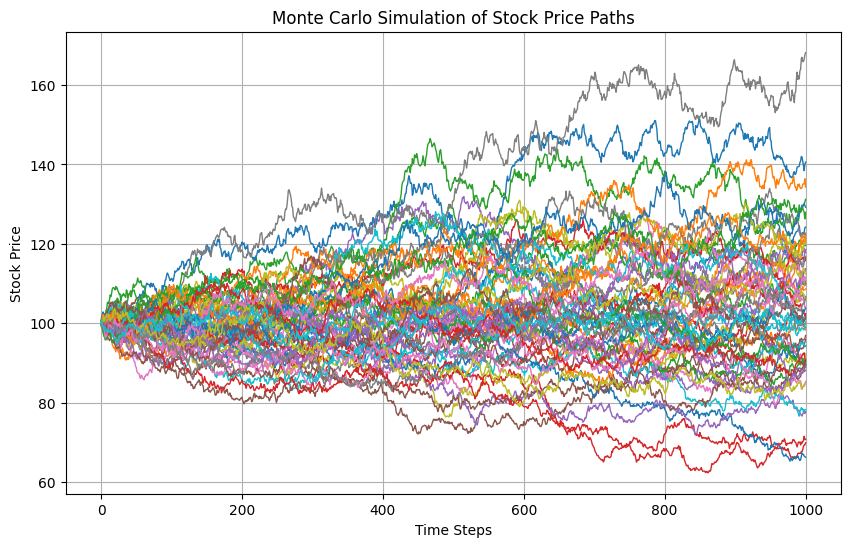

European Call Option Value 7.973
European Put Option Value 7.898


In [5]:
# Call the function
np.random.seed(1000)
C0, P0 = mb_monte_carlo_european_option_pricing()
print("European Call Option Value %5.3f" % C0)
print("European Put Option Value %5.3f" % P0)


In [6]:
def mb_monte_carlo_european_option_pricing_t_distribution(
    S0=100, K=105, T=1.0, r=0.05, sigma=0.2,
    M=1000, I=50000, df=5,
    plot_paths=True, npath_plt=60
):
    """
    Parameters:
    S0 (float): initial stock price
    K (float): strike price
    T (float): time-to-maturity
    r (float): risk-free rate
    sigma (float): volatility
    M (int): number of time steps
    I (int): number of simulation paths
    df (int): degrees of freedom for the Student's t-distribution
    plot_paths (bool): whether to plot simulated paths
    npath_plt (int): number of paths to plot (if enabled)

    Returns:
    C0 (float): European Call Option Value
    P0 (float): European Put Option Value
    """
    start_time = time.time()

    # Set seed for reproducibility
    np.random.seed(1000)

    dt = T / M
    df_adjustment = np.sqrt((df - 2) / df)

    S = np.zeros((M + 1, I))
    S[0] = S0

    for t in range(1, M + 1):
        z = student_t.rvs(df, size=I) * df_adjustment
        S[t] = S[t - 1] * np.exp(
            (r - 0.5 * sigma ** 2) * dt + sigma * np.sqrt(dt) * z
        )

    # Monte Carlo estimators
    C0 = np.exp(-r * T) * np.mean(np.maximum(S[-1] - K, 0))
    P0 = np.exp(-r * T) * np.mean(np.maximum(K - S[-1], 0))

    end_time = time.time()
    print(f"Execution time: {end_time - start_time:.2f} seconds")

    # Optional path plotting (diagnostic / educational only)
    if plot_paths:
        plt.figure(figsize=(10, 6))
        for i in range(min(npath_plt, I)):
            plt.plot(S[:, i], lw=1)
        plt.title("Monte Carlo Simulation of Stock Price Paths (t-distribution)")
        plt.xlabel("Time Steps")
        plt.ylabel("Stock Price")
        plt.grid(True)
        plt.show()

    return C0, P0
    

Execution time: 2.49 seconds


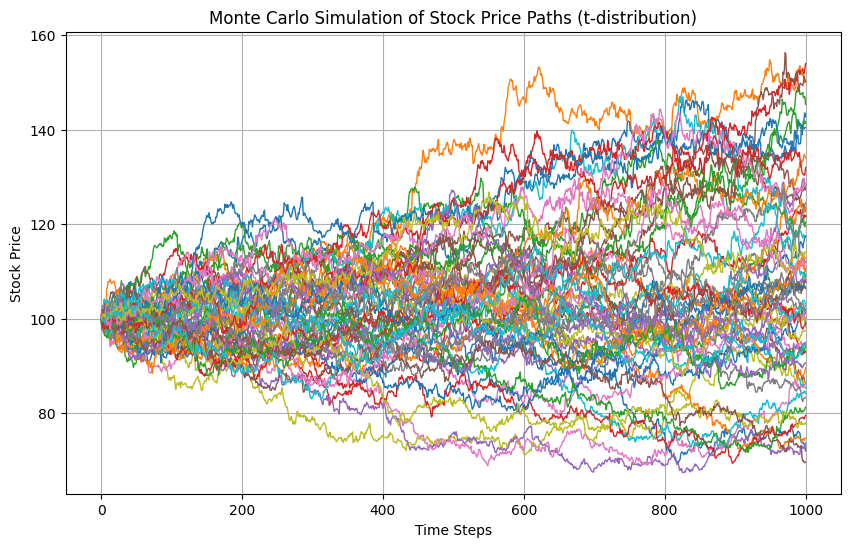

European Call Option Value 8.017
European Put Option Value 7.937


In [7]:
# Call the function
np.random.seed(1000)
C0, P0 = mb_monte_carlo_european_option_pricing_t_distribution()
print("European Call Option Value %5.3f" % C0)
print("European Put Option Value %5.3f" % P0)


## Pricing an American Option with MCS

In [8]:
def mb_monte_carlo_american_option_pricing_t_distribution(
    S0=100, K=105, T=1.0, r=0.05, sigma=0.2,
    M=1000, I=50000, df=5, basis_degree=2, seed=None
):
    """
    Longstaff–Schwartz Monte Carlo (LSM) for American call & put.
    Student-t innovations rescaled to unit variance (df > 2).

    Returns:
      C0 (float): American call price
      P0 (float): American put price
    """
    if df <= 2:
        raise ValueError("df must be > 2 so Student-t has finite variance.")
    if seed is not None:
        np.random.seed(seed)

    start_time = time.time()

    dt = T / M
    disc = np.exp(-r * dt)

    # Rescale t to have variance 1:
    # Var(t_df) = df/(df-2) => multiply by sqrt((df-2)/df)
    t_scale = np.sqrt((df - 2) / df)

    # Simulate paths
    S = np.empty((M + 1, I), dtype=float)
    S[0] = S0

    drift = (r - 0.5 * sigma**2) * dt
    vol   = sigma * np.sqrt(dt)

    for step in range(1, M + 1):
        z = student_t.rvs(df, size=I) * t_scale
        S[step] = S[step - 1] * np.exp(drift + vol * z)

    def lsm_american_price(payoff_fn):
        # Cashflow at maturity (time M)
        CF = payoff_fn(S[M])

        # Backward induction: t = M-1 ... 1
        for t in range(M - 1, 0, -1):
            # Discount the already-determined future cashflow back one step
            CF *= disc

            intrinsic = payoff_fn(S[t])
            itm = intrinsic > 0

            # If nothing is ITM, nothing to regress; continue
            if not np.any(itm):
                continue

            X = S[t, itm]

            # Basis functions: [1, S, S^2, ...]
            if basis_degree == 1:
                A = np.column_stack([np.ones_like(X), X])
            else:
                cols = [np.ones_like(X)]
                for p in range(1, basis_degree + 1):
                    cols.append(X**p)
                A = np.column_stack(cols)

            # Regress discounted future cashflow on basis
            reg = LinearRegression(fit_intercept=False)
            reg.fit(A, CF[itm])
            continuation = reg.predict(A)

            # Exercise decision
            exercise = intrinsic[itm] > continuation

            # If exercise now, replace future CF with intrinsic (already at time t)
            idx_itm = np.where(itm)[0]
            ex_idx = idx_itm[exercise]
            CF[ex_idx] = intrinsic[ex_idx]

        # Discount from time 1 to time 0
        return np.mean(CF) * disc

    call_payoff = lambda x: np.maximum(x - K, 0.0)
    put_payoff  = lambda x: np.maximum(K - x, 0.0)

    C0 = lsm_american_price(call_payoff)
    P0 = lsm_american_price(put_payoff)

    end_time = time.time()
    print(f"Execution time: {end_time - start_time:.2f} seconds")

    return C0, P0


In [9]:
# Call the function
np.random.seed(1000)
C0, P0 = mb_monte_carlo_american_option_pricing_t_distribution()
print("American Call Option Value %5.3f" % C0)
print("American Put Option Value %5.3f" % P0)


Execution time: 5.95 seconds
American Call Option Value 8.017
American Put Option Value 8.667
